<img src="https://www.pucsp.br/sites/default/files/download/brasao-PUCSP-assinatura-principal-RGB.png" style="float:right;" width="150px">

# Ciências da Computação [》](https://www.pucsp.br/graduacao/ciencia-da-computacao)

## Inteligência Artificial

IA ML (Machine Learning, Aprendizagem de Máquina)

**Objetivo deste LAB explorar os modelos de Regressão Linear e Regressão Logística com Scikit-Learn em Python, sobre os dados de "Happines por idade e país"**

- Regressão Linear: <br>
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

- Regressão Logistica: <br>
https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

# LAB: Felicidade por Idade e por País

> ### Informações da atividade
>
> - **Formato:** projeto em **dupla** pairing - [pair programming](https://en.wikipedia.org/wiki/Pair_programming) (2 estudantes). Os dois participam de todas as etapas e os dois precisam ter commits no repositório.
> - **Prazo:** até o **final do dia** da aula LAB. A atividade **pode ser feita durante a aula de laboratório**.
> - **Publicação:** publiquem o projeto no **GitHub**, como item do **portfólio** da dupla, e enviem o **link do repositório** na **atividade do MS Teams**.

**Dupla**

| | Nome | Usuário no GitHub |
| --- | --- | --- |
| Integrante 1 | *Luís Augusto Coelho de Souza* | *https://github.com/Luis-coelho30* |
| Integrante 2 | *Guilherme Schnekenberg Teixeira* | *https://github.com/schnekenberg* |

**Checklist de entrega** (os detalhes estão na Seção 10)

- [ ] O notebook roda de cima para baixo em um kernel limpo (*Restart & Run All*) e foi salvo **com as saídas** (gráficos e tabelas).
- [ ] O repositório no GitHub tem `README.md`, `requirements.txt`, `lab_helpers.py` (opcional) e este notebook.
- [ ] Os dois integrantes têm commits no repositório.
- [ ] O link do repositório foi enviado na atividade do MS Teams.

## 1. Contexto

Neste laboratório vamos testar uma das afirmações mais debatidas na pesquisa sobre felicidade: a de que a satisfação com a vida segue uma **curva em U** ao longo da idade, e de que o formato dessa curva depende de onde a pessoa vive. Vocês vão construir o pipeline completo, dos dados brutos ao modelo ajustado, usando **Python, scikit-learn e Seaborn**.

Pesquisadores medem bem-estar com a **escada de Cantril** (*Cantril ladder*): a pessoa avalia sua vida atual de 0 (pior vida possível) a 10 (melhor vida possível). O **Gallup World Poll** faz essa pergunta em amostras nacionalmente representativas em mais de 140 países, e o **World Happiness Report (WHR)** publica as médias nacionais, em geral como médias móveis de três anos.

Duas histórias concorrentes sobre a idade aparecem nesses dados:

- **A curva em U clássica.** Estudos do Reino Unido e de outros países de renda alta mostram a felicidade caindo a partir dos 20 anos, até os 40 ou início dos 50, e depois subindo até se estabilizar por volta dos 70. As explicações incluem a pressão da meia-idade (emprego, filhos, cuidado com pais idosos) e a adaptação e as expectativas menores na velhice.
- **Um alvo em movimento.** O capítulo sobre idade do WHR 2024 mostra que a felicidade dos jovens (15 a 24 anos) na América do Norte caiu bastante desde 2006-2010, e hoje eles estão menos felizes que os mais velhos. Na Europa Central e Oriental aconteceu o oposto: a felicidade subiu em todas as idades. Quem nasceu depois de 1980 também relata avaliações de vida menores que as coortes anteriores.

*The Happiness Curve* é a versão popular, em formato de livro, da primeira história. O projeto de vocês é ver quanto de cada história sobrevive aos dados, e perceber o que renda, população e área do país mudam nesse quadro.

**Por que isso é um bom exercício de ML.** A pergunta se traduz em duas tarefas supervisionadas clássicas. Prever uma nota (0 a 10) a partir de idade e características do país é **regressão**. Prever se um grupo está acima ou abaixo de um limiar de felicidade é **classificação**. A curva em U também traz uma lição embutida: uma reta é o modelo errado para a idade, e vocês devem ser capazes de mostrar por quê.

## 2. Objetivos de aprendizagem e pré-requisitos

Ao final do laboratório, seremos capazes de construir, avaliar e explicar dois modelos do scikit-learn sobre um conjunto de dados combinado de várias fontes, dizendo com honestidade o que eles mostram e o que não mostram. Organize o tempo de laboratório, mais as leituras. Como o projeto é em dupla, a divisão de trabalho sugerida está abaixo.

Vocês serão capazes de:

- Combinar dados de pesquisa com indicadores do Banco Mundial usando uma chave de país, e auditar o *join* para achar países sem correspondência.
- Criar atributos (*features*) a partir de grandezas assimétricas (log do PIB per capita, log da população, log da área) e explicar o motivo.
- Ajustar uma regressão linear e visualizá-la com Seaborn, mostrando que um termo quadrático na idade supera a reta.
- Transformar uma variável numérica em rótulo binário, ajustar uma regressão logística e embrulhá-la em uma função reutilizável que devolve P(feliz) para uma idade e um país.
- Avaliar com uma divisão **agrupada por país**, para que o modelo seja testado em países que nunca viu.

**Pré-requisitos:** noções de pandas, o padrão `fit` / `predict` do scikit-learn e um laboratório anterior sobre divisão treino/teste.

In [10]:
# Instalação (rode uma vez, se necessário). Remova o "#" da linha abaixo:
%pip install pandas numpy scikit-learn seaborn matplotlib requests openpyxl country_converter

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import io
import requests

sns.set_theme(style="whitegrid", context="talk")
RANDOM_STATE = 42   # semente fixa: seus resultados precisam ser reproduzíveis

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


## 3. Passo 0: leia antes de programar

Leiam as quatro fontes e escrevam **uma frase por fonte** respondendo à pergunta da tabela. Vocês vão reaproveitar essas frases na discussão final.

| Fonte | O que extrair |
| --- | --- |
| [Gallup: World Happiness Report](https://www.gallup.com/analytics/349487/world-happiness-report.aspx) | Qual é exatamente a pergunta da escada de Cantril? Quem é entrevistado, e por que as notas nacionais são médias de três anos? |
| [WEF: At what age does happiness peak?](https://www.weforum.org/stories/wellbeing-and-mental-health/at-what-age-does-happiness-peak/) | Onde fica o mínimo da curva em U, e em quais dados de países de renda alta a afirmação se apoia? Quais mecanismos são propostos? |
| [World Happiness Report 2024: Happiness and age (resumo)](https://www.worldhappiness.report/ed/2024/happiness-and-age-summary/) | Quais regiões quebram o padrão em U? O que é diferente em quem nasceu depois de 1980? Quais faixas etárias o relatório usa? |
| [The Happiness Curve (Macmillan)](https://us.macmillan.com/books/9781427292988/thehappinesscurve/)  - OPCIONAL | Qual é o argumento central do livro, e vocês esperariam que ele valesse para um país de renda baixa? |

Dois detalhes que vocês vão usar depois. O capítulo de idade do WHR 2024 usa **quatro faixas etárias** (menos de 30, 30-44, 45-59 e 60+), então o conjunto de dados de vocês também terá quatro. E ele compara as médias de 2021-2023 com uma base de 2006-2010, então **sempre registrem a que anos os seus dados se referem**. Os números por faixa etária que vocês vão baixar na Parte 1 vêm do [Our World in Data](https://ourworldindata.org/grapher/cantril-ladder-age-groups?tab=table), que republica os resultados do WHR 2024; deem uma olhada na visualização em tabela agora.

**Minhas notas de leitura**

1. **Gallup:** A escada de Cantril pede que o respondente avalie sua vida atual numa escala de 0 (pior vida possível) a 10 (melhor vida possível), são entrevistadas amostras nacionalmente representativas em mais de 140 países pelo Gallup World Poll, variando de 1000 a 2000 respondentes e as notas nacionais são médias de três anos para reduzir a volatilidade anual e tornar as comparações entre países mais confiáveis.
2. **WEF:** O mínimo da curva em U fica entre 40 e 50 anos, com base em dados do ONS britânico, um estudo no PNAS (satisfação com a vida em países de renda alta) e um artigo no The Lancet (relatos de preocupação e estresse). Os mecanismos propostos avaliam condições externas (responsabilidades conflitantes de trabalho e família) e internas (comparações sobre o estado atual da vida e adaptação psicológica).
3. **WHR 2024:** As regiões que quebram o padrão em U são América do Norte (queda especialmente entre os jovens), Sul da Ásia e Oriente Médio/Norte da África (queda em todas as faixas etárias). Os nascidos após 1980 apresentam avaliações de vida mais baixas do que gerações anteriores, com a felicidade caindo a cada ano. O relatório usa as faixas etárias de pessoas com menos de 30, 30–44, 45–59 e 60+.
4. **The Happiness Curve:** A satisfação com a vida segue uma trajetória em formato de U ao longo dos anos, caindo do otimismo da juventude até atingir um ponto mais baixo na meia-idade (por volta dos 45 a 50 anos) e voltando a subir de forma consistente na velhice. A curva em U em geral não deveria se sustentar em países de baixa renda, devido a condições de vida precárias existentes até mesmo no final da vida.

## 4. Fluxo de trabalho sugerido

Trabalhem em seis etapas, em um único notebook, com uma célula de texto (markdown) com as **palavras de vocês** acima de cada célula de código. Cada etapa produz algo que dá para conferir antes de seguir.

**0 Ler → 1 Baixar os dados → 2 Enriquecer (PIB, população, área) → 3 Regressão linear + gráficos → 4 Regressão logística → 5 Discutir os limites**

| Processo | Etapa | Vocês terminaram quando | Tempo sugerido |
| --- | --- | --- | --- |
| ASK | 0 Ler | Há uma frase por fonte (Seção 3) | 60 min |
| GET | 1 Baixar | `age` tem 4 linhas por país e nenhum `ladder_mean` faltando | 30 min |
| EXPLORE | 2 Enriquecer | Todo país mantido tem PIB, população e área; a lista de países descartados foi impressa | 40 min |
| MODEL | 3 Linear | Duas figuras do Seaborn e uma tabela comparando três modelos com R² e RMSE em validação cruzada | 60 min |
| MODEL | 4 Logística | `check_happiness(country, age)` devolve uma probabilidade, e vocês reportam acurácia e AUC em países não vistos | 60 min |
| COMMUNICATE | 5 Discutir | Meia página respondendo às perguntas da Seção 9 | 30 min |

> É bem factível terminar o projeto durante o LAB trabalhando em equipe

**Escolhas de projeto já feitas por nós**, para que os resultados sejam comparáveis entre as duplas: a variável-alvo é a média da escada de Cantril, a idade entra como o **ponto médio** da faixa, o PIB é per capita em PPC (paridade do poder de compra) e todas as grandezas assimétricas passam por logaritmo. Vocês podem mudar qualquer uma delas, e podem acrescentar os dados extras que acharem úteis (veja o fim da Seção 6), desde que informem isso no relatório.

**Sugestão de divisão do trabalho na dupla.** Os dois fazem as leituras (Passo 0) e a discussão final juntos. A pessoa A fica com as Partes 1 e 3 (dados e regressão linear); a pessoa B, com as Partes 2 e 4 (enriquecimento e regressão logística). Antes de seguir para a etapa seguinte, um revisa o código do outro. Usem branches e *pull requests* no GitHub, ou pelo menos façam commits frequentes com mensagens claras.

## 5. Parte 1: configuração e download dos dados

Os dados por idade são **gratuitos e públicos**: o Our World in Data (OWID) republica os resultados por faixa etária do WHR 2024, enquanto os downloads do próprio WHR não trazem divisão por idade. A [página de compartilhamento de dados do WHR](https://www.worldhappiness.report/data-sharing/) oferece a planilha da Figura 2.1 (médias nacionais de três anos desde 2012) e apêndices estatísticos. Vocês vão combinar duas fontes:

| Fonte | O que entrega | Como obter |
| --- | --- | --- |
| [OWID: Self-reported life satisfaction by age](https://ourworldindata.org/grapher/cantril-ladder-age-groups?tab=table) | Média da escada de Cantril em quatro faixas etárias (até 29, 30-44, 45-59, 60+) em cerca de 195 países, média de 2021-2023, com códigos de país ISO3. Licença CC BY. | Download de CSV, em formato largo (uma linha por país) |
| [Planilha da Figura 2.1 do WHR](https://files.worldhappiness.report/WHR26_Data_Figure_2.1.xlsx) | Nota nacional geral (médias de três anos desde 2012), intervalos de confiança e fatores explicativos | Arquivo Excel |
| Arquivo do professor (opcional) | As mesmas faixas etárias para outros anos, em formato longo | Fornecido em aula |

O arquivo do OWID tem as colunas `Entity`, `Code`, `Year`, `Up to 29 years`, `30-44 years`, `45-59 years` e `60+ years`. `Code` é o código de país ISO3, então dá para juntar com os dados do Banco Mundial sem comparar nomes.


#### **Tarefa 1.1.** 

Criem a pasta do projeto e um ambiente virtual, instalem os pacotes da Seção 2 e coloquem o arquivo `lab_helpers.py` (fornecido pelo professor) ao lado deste notebook. Ele também precisa ir para o repositório do GitHub.

#### **Tarefa 1.2.** 
Abram a [visualização em tabela do OWID](https://ourworldindata.org/grapher/cantril-ladder-age-groups?tab=table), leiam o CSV vocês mesmos e inspecionem. Depois transformem de largo para longo com `melt`, de modo que haja uma linha por país e faixa etária. Por fim, comparem o resultado com `load_owid_age()`, que faz o mesmo e ainda descarta linhas sem código de país.

In [11]:
OWID_AGE_URL = 'https://ourworldindata.org/grapher/cantril-ladder-age-groups.csv?v=1&csvType=full&useColumnShortNames=true'

raw = pd.read_csv(OWID_AGE_URL, storage_options={'User-Agent': 'Our World In Data data fetch/1.0'})
print(raw.shape)
display(raw.head())
print(raw.isna().sum())
raw.rename(columns={"entity": "country"}, inplace=True)

age = pd.melt(raw, id_vars=["country", "code", "year"], var_name="age_group", value_name="ladder_mean")
print(age.shape)
print(age.groupby("code").size().value_counts())

(143, 7)


,entity,code,year,cantril_ladder_score__age_group_up_to_29_years,cantril_ladder_score__age_group_30_44_years,cantril_ladder_score__age_group_45_59_years,cantril_ladder_score__age_group_60plus_years
0,Afghanistan,AFG,2023,1.827,1.617,1.681,1.456
1,Albania,ALB,2023,6.358,5.289,4.704,4.643
2,Algeria,DZA,2023,5.379,5.290,5.261,5.631
3,Argentina,ARG,2023,6.746,6.119,5.676,5.948
4,Armenia,ARM,2023,6.245,5.448,5.032,4.865


entity                                            0
code                                              0
year                                              0
cantril_ladder_score__age_group_up_to_29_years    0
cantril_ladder_score__age_group_30_44_years       0
cantril_ladder_score__age_group_45_59_years       0
cantril_ladder_score__age_group_60plus_years      0
dtype: int64
(572, 5)
4    143
Name: count, dtype: int64


Acrescentando os códigos ISO3 oficiais a partir da coluna entity do OWID com oficiais para evitar conflitos com o World Bank Data

In [12]:
import country_converter as coco

cc = coco.CountryConverter()

def to_iso3(name: str) -> str:
  special_cases = {
      "Kosovo": "XKX",
  }
  
  if name in special_cases:
      return special_cases[name]
  
  result = cc.convert(name, to="ISO3")
  
  return result if result != "not found" else pd.NA

In [13]:
age["iso3"] = age["country"].apply(to_iso3)

display(age["iso3"])

age["iso3"].isna().sum()

0      AFG
1      ALB
2      DZA
3      ARG
4      ARM
      ... 
567    VEN
568    VNM
569    YEM
570    ZMB
571    ZWE
Name: iso3, Length: 572, dtype: str

np.int64(0)

#### **Tarefa 1.3.** 
Baixem a planilha da Figura 2.1 com `pd.read_excel`. **Imprimam as colunas antes de usar qualquer uma**, porque os nomes mudam entre as edições do relatório e não devem ser copiados de um tutorial antigo. Usem a planilha como verificação de sanidade: a média das quatro faixas etárias de um país deve ficar perto da nota geral dele, mas não idêntica, porque as fontes ponderam e definem as janelas de tempo de formas diferentes.

In [14]:
WHR_XLSX = "https://files.worldhappiness.report/WHR26_Data_Figure_2.1.xlsx"

response = requests.get(WHR_XLSX)

whr = pd.read_excel(io.BytesIO(response.content))

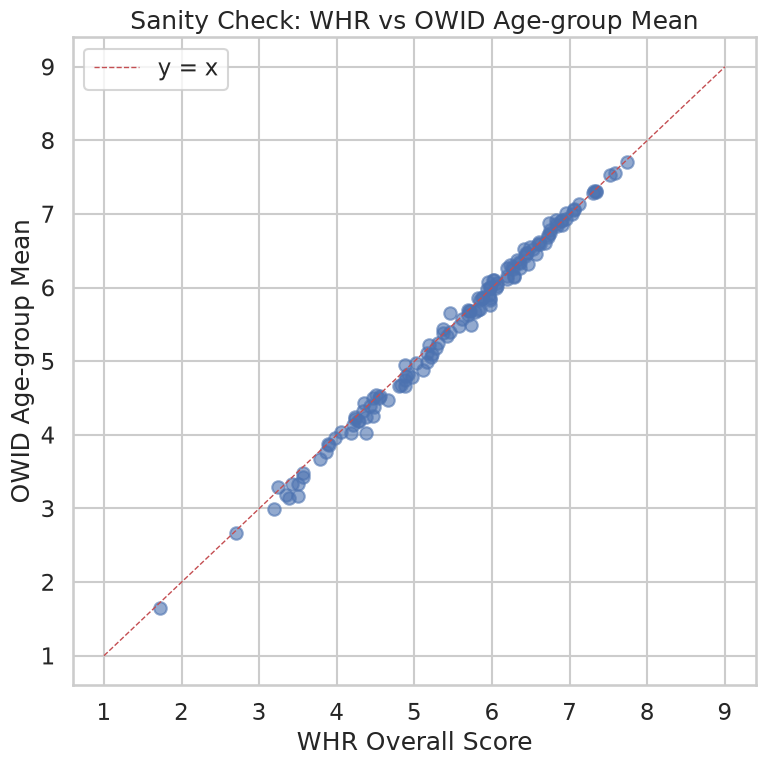

In [15]:
import matplotlib.pyplot as plt

# filters data to match the OWID age window
whr_2023 = whr[whr['Year'] == 2023]

# build comparison df
comparison = (
  age.groupby('country')['ladder_mean']
  .mean()
  .reset_index()
  .merge(whr_2023[['Country name', 'Life evaluation (3-year average)']],
         left_on='country', right_on='Country name')
)

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(
  comparison['Life evaluation (3-year average)'],
  comparison['ladder_mean'],
  alpha=0.6
)

# reference line y=x
lims = [1, 9]
ax.plot(lims, lims, 'r--', linewidth=1, label='y = x')

ax.set_xlabel('WHR Overall Score')
ax.set_ylabel('OWID Age-group Mean')
ax.set_title('Sanity Check: WHR vs OWID Age-group Mean')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Parte 2: enriquecer com PIB, população e tamanho do país

A felicidade varia muito mais **entre países** do que **entre faixas etárias**, então vocês precisam de controles no nível do país antes que o efeito da idade signifique alguma coisa. Vocês vão buscar três indicadores do Banco Mundial pela API pública e juntá-los pelo código **ISO3**, e não pelo nome.

| Atributo | Indicador do Banco Mundial | Por que transformar |
| --- | --- | --- |
| PIB per capita, PPC (dólares internacionais constantes) | `NY.GDP.PCAP.PP.KD` | A renda tem retornos decrescentes, então use `log` |
| População | `SP.POP.TOTL` | Varia em 5 ordens de grandeza (Islândia a Índia), então use `log` |
| Área terrestre (km²) | `AG.LND.TOTL.K2` | Mesma assimetria da população, então use `log` |

`lab_helpers.build_country_table()` chama a API, guarda o último valor não faltante de 2019 a 2023 para cada indicador e descarta os agregados regionais (como "World" e "Arab World") que a API mistura com os países. **Leiam o código antes de rodar**: a resposta é uma lista de dois elementos, com os metadados primeiro e os registros depois.

#### **Tarefa 2.1.**
Confiram as chaves de país. O arquivo do OWID já traz códigos ISO3 na coluna `iso3`, então os dados por idade não precisam de comparação de nomes. Usem `to_iso3` só para fontes que trazem apenas o nome do país (a planilha do WHR, por exemplo), e leiam a lista de nomes sem correspondência que ela imprime.

Comparing World Bank's country dataset to our ISO3 codes generated previously, we can notice all codes match except Taiwan's, as the World Bank does not recognize it as a member country due to geopolitical reasons.

In [16]:
url = "https://api.worldbank.org/v2/country?format=json&per_page=300"

response = requests.get(url)
data = response.json()

wb_countries = pd.DataFrame([
  {"name": c["name"], "code_wb": c["id"]}
  for c in data[1]
])

comparison = age[["country", "iso3"]].drop_duplicates().merge(
  wb_countries,
  left_on="iso3",
  right_on="code_wb",
  how="left",
  indicator=True
)

comparison[comparison["_merge"] != "both"]

,country,iso3,name,code_wb,_merge
124,Taiwan,TWN,NaN,NaN,left_only


#### **Tarefa 2.2.**
Juntem a tabela de idade com a tabela de países usando `validate="many_to_one"`. Depois imprimam os países que perderam dados porque o Banco Mundial não tem valor para eles.

##### **Tarefa 2.2.1**

Extracting country population data from World Bank data

In [17]:
from lab_helpers import read_zip_wbd

wbd_pop = read_zip_wbd("SP.POP.TOTL")

wbd_pop.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"Population, total",SP.POP.TOTL,54922.0,55578.0,56320.0,57002.0,57619.0,58190.0,...,108735.0,108908.0,109203.0,108587.0,107700.0,107310.0,107359.0,107995.0,108785.0,NaN
1,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,130075728.0,133534923.0,137171659.0,140945536.0,144904094.0,149033472.0,...,640058741.0,657801085.0,675950189.0,694446100.0,713090928.0,731821393.0,750491370.0,769280888.0,788844284.0,NaN
2,Afghanistan,AFG,"Population, total",SP.POP.TOTL,9035043.0,9214083.0,9404406.0,9604487.0,9814318.0,10036008.0,...,35688935.0,36743039.0,37856121.0,39068979.0,40000412.0,40578842.0,41454761.0,42647492.0,43844111.0,NaN
3,Africa Western and Central,AFW,"Population, total",SP.POP.TOTL,97630925.0,99706674.0,101854756.0,104089175.0,106384410.0,108754449.0,...,440150152.0,451395343.0,462522286.0,473687685.0,484978794.0,496366058.0,508318102.0,520655398.0,532809933.0,NaN
4,Angola,AGO,"Population, total",SP.POP.TOTL,5231654.0,5301583.0,5354310.0,5408320.0,5464187.0,5521981.0,...,30234839.0,31297155.0,32375632.0,33451132.0,34532429.0,35635029.0,36749906.0,37885849.0,39040039.0,NaN


In [18]:
# Builds World Population table containing data from 2019 to 2023
wbd_pop_melted = wbd_pop.melt(
  id_vars=["Country Name", "Country Code"],
  value_vars=[str(y) for y in range(2019, 2024)],
  var_name="year",
  value_name="population"
)

wbd_pop_melted.rename(columns={"Country Name": "country", "Country Code": "iso3"}, inplace=True)

display(wbd_pop_melted.head())
display(wbd_pop_melted.groupby("iso3").size().value_counts())
display(wbd_pop_melted.isnull().sum())

,country,iso3,year,population
0,Aruba,ABW,2019,109203.0
1,Africa Eastern and Southern,AFE,2019,675950189.0
2,Afghanistan,AFG,2019,37856121.0
3,Africa Western and Central,AFW,2019,462522286.0
4,Angola,AGO,2019,32375632.0


5    265
Name: count, dtype: int64

country       0
iso3          0
year          0
population    5
dtype: int64

##### **Tarefa 2.2.2**

Extracting country area data from World Bank data

In [19]:
from lab_helpers import read_zip_wbd

wbd_area = read_zip_wbd("AG.LND.TOTL.K2")

wbd_area.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,Land area (sq. km),AG.LND.TOTL.K2,NaN,180.0,180.0,180.0,180.0,180.0,...,1.800000e+02,1.800000e+02,1.800000e+02,1.800000e+02,180.0,180.0,180.0,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Land area (sq. km),AG.LND.TOTL.K2,NaN,11094611.0,11094611.0,11094611.0,11094611.0,11094611.0,...,1.485097e+07,1.485294e+07,1.485491e+07,1.485683e+07,14856898.1,14856891.3,14856891.3,NaN,NaN,NaN
2,Afghanistan,AFG,Land area (sq. km),AG.LND.TOTL.K2,NaN,652230.0,652230.0,652230.0,652230.0,652230.0,...,6.522300e+05,6.522300e+05,6.522300e+05,6.522300e+05,652230.0,652230.0,652230.0,NaN,NaN,NaN
3,Africa Western and Central,AFW,Land area (sq. km),AG.LND.TOTL.K2,NaN,9046580.0,9046580.0,9046580.0,9046580.0,9046580.0,...,9.045780e+06,9.045780e+06,9.045773e+06,9.045770e+06,9045773.0,9045773.0,9045773.0,NaN,NaN,NaN
4,Angola,AGO,Land area (sq. km),AG.LND.TOTL.K2,NaN,1246700.0,1246700.0,1246700.0,1246700.0,1246700.0,...,1.246700e+06,1.246700e+06,1.246700e+06,1.246700e+06,1246700.0,1246700.0,1246700.0,NaN,NaN,NaN


In [20]:
# Builds World Area table containing data from 2019 to 2023
wbd_area_melted = wbd_area.melt(
  id_vars=["Country Name", "Country Code"],
  value_vars=[str(y) for y in range(2019, 2024)],
  var_name="year",
  value_name="area_km2"
)

wbd_area_melted.rename(columns={"Country Name": "country", "Country Code": "iso3"}, inplace=True)

display(wbd_area_melted.head())
display(wbd_area_melted.groupby("iso3").size().value_counts())
display(wbd_area_melted.isnull().sum())

,country,iso3,year,area_km2
0,Aruba,ABW,2019,1.800000e+02
1,Africa Eastern and Southern,AFE,2019,1.485491e+07
2,Afghanistan,AFG,2019,6.522300e+05
3,Africa Western and Central,AFW,2019,9.045773e+06
4,Angola,AGO,2019,1.246700e+06


5    265
Name: count, dtype: int64

country      0
iso3         0
year         0
area_km2    12
dtype: int64

##### **Tarefa 2.2.3**

Extracting country gdp data from World Bank data

In [21]:
from lab_helpers import read_zip_wbd

wbd_gdp = read_zip_wbd("NY.GDP.PCAP.PP.KD")

wbd_gdp.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"GDP per capita, PPP (constant 2021 internation...",NY.GDP.PCAP.PP.KD,NaN,NaN,NaN,NaN,NaN,NaN,...,38213.289239,39378.228411,39754.560072,30408.827090,35207.170909,39083.461640,42783.248907,45428.002728,NaN,NaN
1,Africa Eastern and Southern,AFE,"GDP per capita, PPP (constant 2021 internation...",NY.GDP.PCAP.PP.KD,NaN,NaN,NaN,NaN,NaN,NaN,...,4223.188050,4229.839634,4200.531044,3978.133502,4049.969513,4098.126192,4076.224898,4099.889812,4164.679177,NaN
2,Afghanistan,AFG,"GDP per capita, PPP (constant 2021 internation...",NY.GDP.PCAP.PP.KD,NaN,NaN,NaN,NaN,NaN,NaN,...,2952.998916,2902.392113,2927.245144,2769.685745,2144.166570,1981.710168,1983.812620,1964.452289,NaN,NaN
3,Africa Western and Central,AFW,"GDP per capita, PPP (constant 2021 internation...",NY.GDP.PCAP.PP.KD,NaN,NaN,NaN,NaN,NaN,NaN,...,6009.516114,6026.527572,6070.284769,5698.766702,5702.134886,5818.483224,5886.796636,6009.084662,6139.587294,NaN
4,Angola,AGO,"GDP per capita, PPP (constant 2021 internation...",NY.GDP.PCAP.PP.KD,NaN,NaN,NaN,NaN,NaN,NaN,...,10565.167648,10154.838923,9712.979449,8904.949006,8720.187687,8750.993630,8597.538788,8752.797471,8760.190820,NaN


In [22]:
# Builds World Area table containing data from 2019 to 2023
wbd_gdp_melted = wbd_gdp.melt(
  id_vars=["Country Name", "Country Code"],
  value_vars=[str(y) for y in range(2019, 2024)],
  var_name="year",
  value_name="gdp_ppc"
)

wbd_gdp_melted.rename(columns={"Country Name": "country", "Country Code": "iso3"}, inplace=True)

display(wbd_gdp_melted.head())
display(wbd_gdp_melted.groupby("iso3").size().value_counts())
display(wbd_gdp_melted.isnull().sum())

,country,iso3,year,gdp_ppc
0,Aruba,ABW,2019,39754.560072
1,Africa Eastern and Southern,AFE,2019,4200.531044
2,Afghanistan,AFG,2019,2927.245144
3,Africa Western and Central,AFW,2019,6070.284769
4,Angola,AGO,2019,9712.979449


5    265
Name: count, dtype: int64

country     0
iso3        0
year        0
gdp_ppc    97
dtype: int64

##### **Tarefa 2.2.4. Building world country data**

In [23]:
# wbd_pop_melted contains population data
# wbd_area_melted contains area data
# wbd_gdp_melted contains gdp_ppc data

world_country = wbd_pop_melted[["iso3", "year", "country", "population"]]
world_country = world_country.merge(wbd_area_melted, on=["country", "iso3", "year"], how="left")
world_country = world_country.merge(wbd_gdp_melted, on=["country", "iso3", "year"], how="left")
world_country["year"] = world_country["year"].astype(int)

display(world_country.head())
display(world_country.groupby("iso3").size().value_counts())
display(world_country.isnull().sum())

,iso3,year,country,population,area_km2,gdp_ppc
0,ABW,2019,Aruba,109203.0,1.800000e+02,39754.560072
1,AFE,2019,Africa Eastern and Southern,675950189.0,1.485491e+07,4200.531044
2,AFG,2019,Afghanistan,37856121.0,6.522300e+05,2927.245144
3,AFW,2019,Africa Western and Central,462522286.0,9.045773e+06,6070.284769
4,AGO,2019,Angola,32375632.0,1.246700e+06,9712.979449


5    265
Name: count, dtype: int64

iso3           0
year           0
country        0
population     5
area_km2      12
gdp_ppc       97
dtype: int64

###### **Tarefa 2.2.4.1. Verifying which countries have missing data in all years (2019-2023)**

In [24]:
# Verifying which countries have missing data in all years (2019-2023)
missing = world_country[
    (world_country["year"].between(2019, 2023)) &
    (world_country[["population", "area_km2", "gdp_ppc"]].isna().any(axis=1))
].copy()

missing["missing_cols"] = missing[["population", "area_km2", "gdp_ppc"]].apply(
    lambda row: ", ".join(row.index[row.isna()]), axis=1
)

missing[["country", "iso3", "missing_cols"]].drop_duplicates()

,country,iso3,missing_cols
11,American Samoa,ASM,gdp_ppc
38,Channel Islands,CHI,gdp_ppc
50,Cuba,CUB,gdp_ppc
69,Eritrea,ERI,gdp_ppc
83,Gibraltar,GIB,gdp_ppc
92,Guam,GUM,gdp_ppc
107,Isle of Man,IMN,gdp_ppc
109,Not classified,INX,"population, area_km2, gdp_ppc"
136,Liechtenstein,LIE,gdp_ppc
146,St. Martin (French part),MAF,gdp_ppc


In [25]:
# Countries on age that have missing columns
age_iso3 = age[["iso3"]].drop_duplicates()

age_missing = age_iso3.merge(
  missing[["iso3", "missing_cols"]].drop_duplicates(),
  on="iso3",
  how="left"
)

age_missing["missing_cols"] = age_missing["missing_cols"].fillna("complete")

not_in_world = ~age_iso3["iso3"].isin(world_country["iso3"])

age_missing.loc[not_in_world, "missing_cols"] = "not in world_country"

age_missing[age_missing['missing_cols'] != "complete"]

,iso3,missing_cols
67,XKX,area_km2
124,TWN,not in world_country
138,VEN,gdp_ppc
140,YEM,gdp_ppc


###### **Tarefa 2.2.4.2. Building world country df from latest data available**

In [26]:
# Filters world_country data from latest data available in the world country df

world_country_latest = world_country.sort_values("year").groupby("iso3").last().reset_index()

display(world_country_latest)

,iso3,year,country,population,area_km2,gdp_ppc
0,ABW,2023,Aruba,107359.0,180.0,42783.248907
1,AFE,2023,Africa Eastern and Southern,750491370.0,14856891.3,4076.224898
2,AFG,2023,Afghanistan,41454761.0,652230.0,1983.812620
3,AFW,2023,Africa Western and Central,508318102.0,9045773.0,5886.796636
4,AGO,2023,Angola,36749906.0,1246700.0,8597.538788
...,...,...,...,...,...,...
260,XKX,2023,Kosovo,1682668.0,NaN,14240.203032
261,YEM,2023,"Yemen, Rep.",39390799.0,527970.0,NaN
262,ZAF,2023,South Africa,63212384.0,1213090.0,13695.375569
263,ZMB,2023,Zambia,20723965.0,743390.0,3673.484197


In [27]:
# Filters world_country data with age df

world_country_latest = world_country_latest[
  world_country_latest["iso3"].isin(age["iso3"])
]

display(world_country_latest)
display(world_country_latest.isnull().sum())

,iso3,year,country,population,area_km2,gdp_ppc
2,AFG,2023,Afghanistan,41454761.0,652230.00,1983.812620
5,ALB,2023,Albania,2411658.0,27400.00,20501.647073
8,ARE,2023,United Arab Emirates,10483751.0,71020.00,70239.832834
9,ARG,2023,Argentina,45538401.0,2736690.00,27230.396850
10,ARM,2023,Armenia,2964300.0,28199.44,19402.751092
...,...,...,...,...,...,...
260,XKX,2023,Kosovo,1682668.0,NaN,14240.203032
261,YEM,2023,"Yemen, Rep.",39390799.0,527970.00,NaN
262,ZAF,2023,South Africa,63212384.0,1213090.00,13695.375569
263,ZMB,2023,Zambia,20723965.0,743390.00,3673.484197


iso3          0
year          0
country       0
population    0
area_km2      1
gdp_ppc       2
dtype: int64

###### **Tarefa 2.2.4.3. Filling missing data using IMF information.**

**Disclaimer:** The countries with missing data (Venezuela, Yemen, Kosovo, and Taiwan) are absent from the World Bank dataset due to crises, geopolitical disputes, or lack of official recognition. Values sourced from the IMF are estimates and should be interpreted with caution in the model outputs.

In [28]:
# Captures gdp data from IMF
IMF_URL = "https://www.imf.org/external/datamapper/api/v1/PPPPC?periods=2023"

response = requests.get(IMF_URL)
data = response.json()

imf_gdp = pd.DataFrame([
    {"iso3": country, "gdp_ppc_imf": values["2023"]}
    for country, values in data["values"]["PPPPC"].items()
    if "2023" in values
])

imf_gdp[imf_gdp['iso3'].isin(['VEN', 'YEM', 'TWN'])]

,iso3,gdp_ppc_imf
167,TWN,74453.656
188,VEN,7888.601
191,YEM,1633.774


In [29]:
taiwan_data = {
  'iso3': 'TWN',
  'area_km2': 35.808, # Data from https://en.wikipedia.org/wiki/Taiwan
  'population': 23342541 # Data from https://eng.stat.gov.tw
}

kosovo_data = {
    'iso3': 'XKX',
    'area_km2': 10.887, # Data from https://en.wikipedia.org/wiki/Kosovo
}

In [30]:
# Fills Taiwan's missing population and area
taiwan_row = pd.DataFrame([{
  "iso3": taiwan_data["iso3"],
  "country": "Taiwan",
  "population": taiwan_data["population"],
  "area_km2": taiwan_data["area_km2"],
}])

world_country_latest = pd.concat([world_country_latest, taiwan_row], ignore_index=True)

# Fills missing Kosovo area
world_country_latest.loc[world_country_latest["iso3"] == kosovo_data["iso3"], "area_km2"] = kosovo_data["area_km2"]

# Fills missing gdp data
world_country_latest = world_country_latest.merge(imf_gdp, on="iso3", how="left")

world_country_latest["gdp_ppc"] = world_country_latest["gdp_ppc"].fillna(
    world_country_latest["gdp_ppc_imf"]
)

world_country_latest.drop(columns=["gdp_ppc_imf"], inplace=True)
display(world_country_latest)
display(world_country_latest.isnull().sum())

,iso3,year,country,population,area_km2,gdp_ppc
0,AFG,2023.0,Afghanistan,41454761.0,652230.000,1983.812620
1,ALB,2023.0,Albania,2411658.0,27400.000,20501.647073
2,ARE,2023.0,United Arab Emirates,10483751.0,71020.000,70239.832834
3,ARG,2023.0,Argentina,45538401.0,2736690.000,27230.396850
4,ARM,2023.0,Armenia,2964300.0,28199.440,19402.751092
...,...,...,...,...,...,...
138,YEM,2023.0,"Yemen, Rep.",39390799.0,527970.000,1633.774000
139,ZAF,2023.0,South Africa,63212384.0,1213090.000,13695.375569
140,ZMB,2023.0,Zambia,20723965.0,743390.000,3673.484197
141,ZWE,2023.0,Zimbabwe,16340822.0,386850.000,5218.045266


iso3          0
year          1
country       0
population    0
area_km2      0
gdp_ppc       0
dtype: int64

###### **Tarefa 2.2.4.4. Merge OWID age data with world country data.**

In [31]:
X = age.merge(
    world_country_latest[["iso3", "population", "area_km2", "gdp_ppc"]],
    on="iso3",
    how="left"
)

display(X.head())
display(X.isnull().sum())

,country,code,year,age_group,ladder_mean,iso3,population,area_km2,gdp_ppc
0,Afghanistan,AFG,2023,cantril_ladder_score__age_group_up_to_29_years,1.827,AFG,41454761.0,652230.00,1983.812620
1,Albania,ALB,2023,cantril_ladder_score__age_group_up_to_29_years,6.358,ALB,2411658.0,27400.00,20501.647073
2,Algeria,DZA,2023,cantril_ladder_score__age_group_up_to_29_years,5.379,DZA,46164219.0,2381740.00,15159.324237
3,Argentina,ARG,2023,cantril_ladder_score__age_group_up_to_29_years,6.746,ARG,45538401.0,2736690.00,27230.396850
4,Armenia,ARM,2023,cantril_ladder_score__age_group_up_to_29_years,6.245,ARM,2964300.0,28199.44,19402.751092


country        0
code           0
year           0
age_group      0
ladder_mean    0
iso3           0
population     0
area_km2       0
gdp_ppc        0
dtype: int64

#### **Tarefa 2.3.**
Criem os atributos: `age_mid` a partir do dicionário `AGE_MID` do `lab_helpers.py`, `age_sq`, `log_gdp_pc`, `log_pop`, `log_area` e `pop_density = pop / area_km2`.

Let age_mid be the midpoint between the age groups in the cantill ladder

In [32]:
age_mid_map = {
  "cantril_ladder_score__age_group_up_to_29_years": 22,
  "cantril_ladder_score__age_group_30_44_years": 37,
  "cantril_ladder_score__age_group_45_59_years": 52,
  "cantril_ladder_score__age_group_60plus_years": 70
}

X["age_mid"] = X["age_group"].map(age_mid_map)
display(X)

,country,code,year,age_group,ladder_mean,iso3,population,area_km2,gdp_ppc,age_mid
0,Afghanistan,AFG,2023,cantril_ladder_score__age_group_up_to_29_years,1.827,AFG,41454761.0,652230.00,1983.812620,22
1,Albania,ALB,2023,cantril_ladder_score__age_group_up_to_29_years,6.358,ALB,2411658.0,27400.00,20501.647073,22
2,Algeria,DZA,2023,cantril_ladder_score__age_group_up_to_29_years,5.379,DZA,46164219.0,2381740.00,15159.324237,22
3,Argentina,ARG,2023,cantril_ladder_score__age_group_up_to_29_years,6.746,ARG,45538401.0,2736690.00,27230.396850,22
4,Armenia,ARM,2023,cantril_ladder_score__age_group_up_to_29_years,6.245,ARM,2964300.0,28199.44,19402.751092,22
...,...,...,...,...,...,...,...,...,...,...
567,Venezuela,VEN,2023,cantril_ladder_score__age_group_60plus_years,5.570,VEN,28300854.0,882050.00,7888.601000,70
568,Vietnam,VNM,2023,cantril_ladder_score__age_group_60plus_years,5.521,VNM,100352192.0,313429.00,13534.799784,70
569,Yemen,YEM,2023,cantril_ladder_score__age_group_60plus_years,3.740,YEM,39390799.0,527970.00,1633.774000,70
570,Zambia,ZMB,2023,cantril_ladder_score__age_group_60plus_years,2.484,ZMB,20723965.0,743390.00,3673.484197,70


In [33]:
X["age_sq"] = X["age_mid"] ** 2
X["log_gdp_ppc"] = np.log(X["gdp_ppc"])
X["log_pop"] = np.log(X["population"])
X["log_area"] = np.log(X["area_km2"])
X["pop_density"] = X["population"] / X["area_km2"]

display(X)

,country,code,year,age_group,ladder_mean,iso3,population,area_km2,gdp_ppc,age_mid,age_sq,log_gdp_ppc,log_pop,log_area,pop_density
0,Afghanistan,AFG,2023,cantril_ladder_score__age_group_up_to_29_years,1.827,AFG,41454761.0,652230.00,1983.812620,22,484,7.592776,17.540113,13.388153,63.558501
1,Albania,ALB,2023,cantril_ladder_score__age_group_up_to_29_years,6.358,ALB,2411658.0,27400.00,20501.647073,22,484,9.928261,14.695825,10.218298,88.016715
2,Algeria,DZA,2023,cantril_ladder_score__age_group_up_to_29_years,5.379,DZA,46164219.0,2381740.00,15159.324237,22,484,9.626371,17.647716,14.683342,19.382560
3,Argentina,ARG,2023,cantril_ladder_score__age_group_up_to_29_years,6.746,ARG,45538401.0,2736690.00,27230.396850,22,484,10.212089,17.634067,14.822260,16.639956
4,Armenia,ARM,2023,cantril_ladder_score__age_group_up_to_29_years,6.245,ARM,2964300.0,28199.44,19402.751092,22,484,9.873170,14.902151,10.247057,105.119109
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
567,Venezuela,VEN,2023,cantril_ladder_score__age_group_60plus_years,5.570,VEN,28300854.0,882050.00,7888.601000,70,4900,8.973174,17.158403,13.690004,32.085317
568,Vietnam,VNM,2023,cantril_ladder_score__age_group_60plus_years,5.521,VNM,100352192.0,313429.00,13534.799784,70,4900,9.513019,18.424196,12.655328,320.175198
569,Yemen,YEM,2023,cantril_ladder_score__age_group_60plus_years,3.740,YEM,39390799.0,527970.00,1633.774000,70,4900,7.398648,17.489043,13.176795,74.608025
570,Zambia,ZMB,2023,cantril_ladder_score__age_group_60plus_years,2.484,ZMB,20723965.0,743390.00,3673.484197,70,4900,8.208896,16.846801,13.518976,27.877648


**Armadilhas para observar:**

- **Códigos que o Banco Mundial não usa.** Alguns territórios podem ter um código que o Banco Mundial não tem. Taiwan, em geral, também não aparece nos dados do Banco Mundial. Olhem os países perdidos na Tarefa 2.2 e decidam, para cada um, se vale corrigir ou descartar.
- **Fontes só com nomes.** Se vocês acrescentarem dados sem coluna ISO3, dois nomes podem virar o mesmo código ("Somaliland region" vira o mesmo código da Somália). Mantenham a asserção acima para que uma colisão dessas falhe de forma visível.
- **Valores defasados.** O PIB do ano mais recente costuma vir em branco, e por isso o auxiliar pega o último valor disponível em uma janela. Informem a janela no relatório.
- `AGE_MID["60+"] = 70` é uma suposição, já que a faixa é aberta. Registrem isso e testem 65 como checagem de robustez.

### Acrescente seus próprios dados (escolha livre)

Os três indicadores do Banco Mundial são um ponto de partida, **não um limite**. Vocês podem acrescentar **qualquer informação** que julguem útil para explicar a felicidade entre idades e países, e não precisam pedir permissão. Algumas ideias:

- Demografia: expectativa de vida, idade mediana, proporção de pessoas acima de 60 anos, urbanização.
- Economia e sociedade: desemprego, desigualdade de renda (Gini), educação, gastos com saúde, uso de internet.
- Os fatores explicativos brutos da planilha do WHR, como apoio social, liberdade, generosidade e percepção de corrupção.
- Geografia e cultura: região, latitude, clima, religião ou idioma predominante.
- Qualquer outro indicador do Banco Mundial (troquem o código em `WB_INDICATORS`) ou qualquer outro conjunto de dados do Our World in Data.

As regras são sobre honestidade, não sobre permissão. **Juntem por ISO3, citem a fonte e a data do download, apliquem logaritmo em variáveis assimétricas** e coloquem as novas colunas em `FEATURES`, para que as Partes 3 e 4 as usem. Depois **mostrem o que mudou**: comparem o RMSE em validação cruzada com e sem as novas colunas na Parte 3, e o AUC na Parte 4. Dois cuidados. **Não usem a nota geral do WHR como atributo**, porque ela é quase a própria variável-alvo. E tratem com cautela as colunas de contribuição ("explained by") da planilha, porque elas são saídas da regressão do próprio relatório.

In [34]:
# (Opcional) Seus dados extras entram aqui.
# Exemplo: outro indicador do Banco Mundial, buscado com a função do auxiliar.
# from lab_helpers import fetch_wb
# extra = fetch_wb("SP.DYN.LE00.IN").rename("life_exp").reset_index()   # expectativa de vida
# df = df.merge(extra, on="iso3", how="left")
# Lembre de documentar: fonte, data do download, anos e chave de junção.

## 7. Parte 3: regressão linear e visualização com Seaborn

O objetivo é mostrar, com gráficos e números de validação cruzada, **se a idade precisa de uma curva em vez de uma reta**, e quanto do quadro é explicado pela riqueza em vez de pela idade. Vocês vão ajustar três modelos aninhados com `sklearn.linear_model.LinearRegression`:

$$\text{M1: } \hat y = \beta_0 + \beta_1\,\text{idade} \qquad$$

$$\text{M2: } \hat y = \beta_0 + \beta_1\,\text{idade} + \beta_2\,\text{idade}^2$$

$$\text{M3: } \hat y = \text{M2} + \beta_3 \ln(\text{PIB pc}) + \beta_4 \ln(\text{pop}) + \beta_5 \ln(\text{área})$$

Em M2 e M3, a curva ajustada vira em **idade = −β₁ / (2β₂)**. Essa é a estimativa de vocês para a idade em que a felicidade atinge o mínimo, e dá para compará-la com os 40 e poucos ou início dos 50 anos citados no artigo do WEF.

##### **Tarefa 3.1. Reta ou curva.** Desenhem lado a lado dois gráficos de dispersão de `ladder_mean` contra `age_mid`, um com `order=1` e outro com `order=2`. O Seaborn ajusta e desenha o polinômio para vocês.

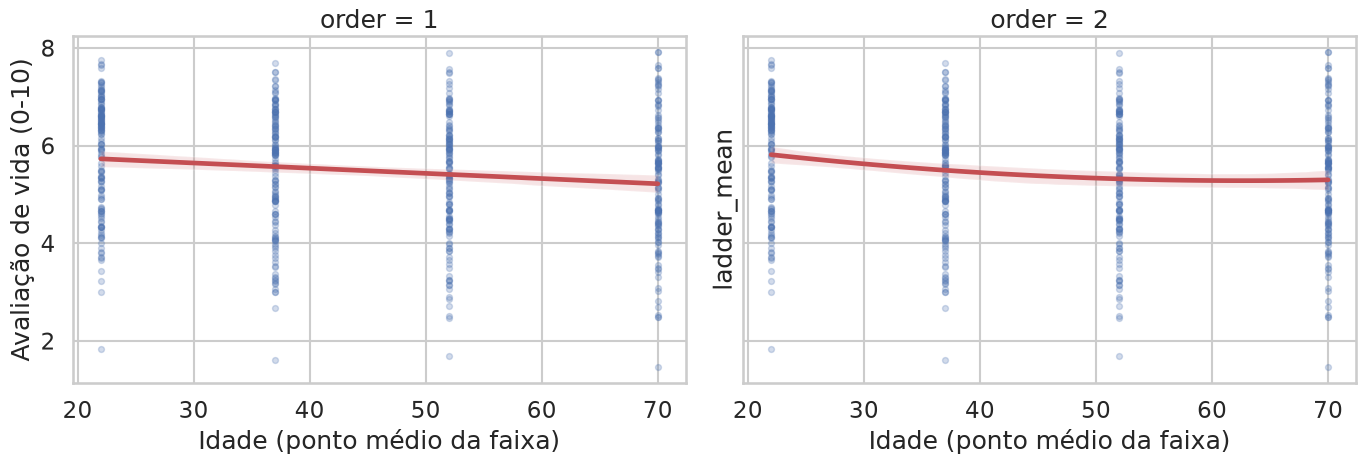

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, order in zip(axes, [1, 2]):
    sns.regplot(data=X, x="age_mid", y="ladder_mean", order=order, ax=ax,
                scatter_kws={"alpha": 0.25, "s": 18}, line_kws={"color": "C3"})
    ax.set_title(f"order = {order}")
    ax.set_xlabel("Idade (ponto médio da faixa)")
axes[0].set_ylabel("Avaliação de vida (0-10)")
plt.tight_layout()
plt.show()

##### **Tarefa 3.2. O perfil da idade dentro dos países.**

Países ricos e pobres ficam em alturas muito diferentes, o que pode esconder o padrão da idade. Subtraiam a média de cada país e plotem o desvio por faixa de renda com `sns.lmplot(..., col="income_tier", order=2)`. Criem as faixas com `pd.qcut(df["gdp_pc"], 3, labels=[...])`.

In [36]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

y = X["ladder_mean"]

# M1
X_m1 = X[["age_mid"]]

# M2
X_m2 = X[["age_mid", "age_sq"]]

# M3
X_m3 = X[["age_mid", "age_sq", "log_gdp_ppc", "log_pop", "log_area"]]

m1 = LinearRegression().fit(X_m1, y)
m2 = LinearRegression().fit(X_m2, y)
m3 = LinearRegression().fit(X_m3, y)

vertex_m2 = -m2.coef_[0] / (2 * m2.coef_[1])
vertex_m3 = -m3.coef_[0] / (2 * m3.coef_[1])

print(f"Idade mínima M2: {vertex_m2:.1f}")
print(f"Idade mínima M3: {vertex_m3:.1f}")

Idade mínima M2: 62.8
Idade mínima M3: 62.8


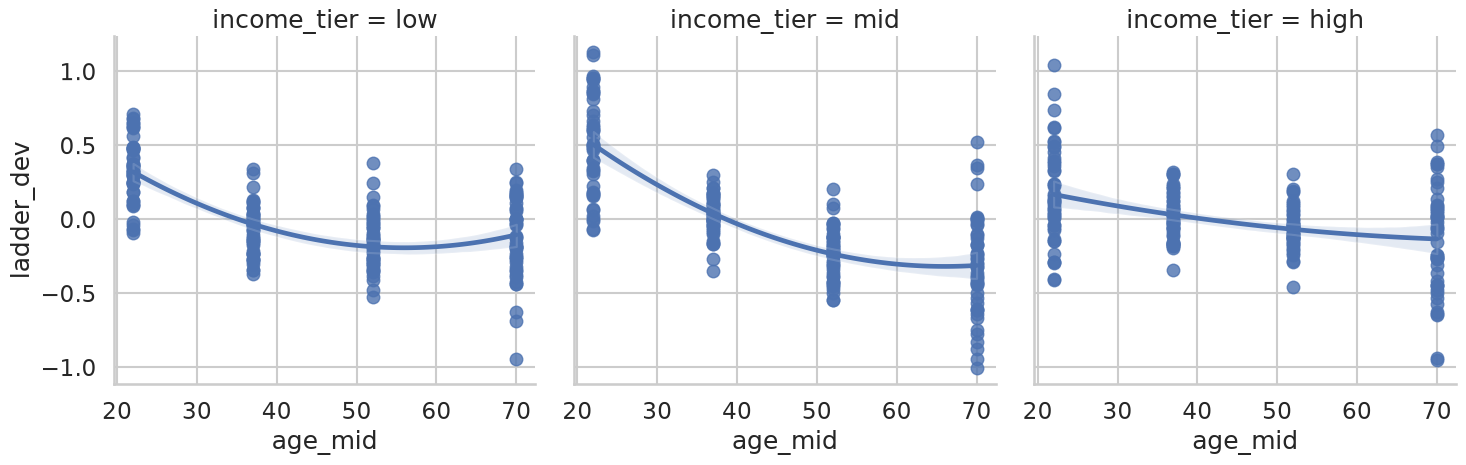

In [37]:
X["ladder_dev"] = X["ladder_mean"] - X.groupby("iso3")["ladder_mean"].transform("mean")

X["income_tier"] = pd.qcut(X["gdp_ppc"], 3, labels=["low", "mid", "high"])

sns.lmplot(
  data=X,
  x="age_mid",
  y="ladder_dev",
  col="income_tier",
  order=2,
)
plt.show()

##### **Tarefa 3.3. Comparem três modelos em países não vistos.**

Uma divisão aleatória de linhas colocaria as outras faixas etárias do mesmo país no treino, então dividam **por país** com `GroupKFold`. Reportem R² e RMSE em validação cruzada para M1, M2 e M3, e depois repitam M1 e M2 com `ladder_dev` como alvo.

In [38]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error

def cv_scores(features, target="ladder_mean", k=5):
  pred = cross_val_predict(LinearRegression(), X[features], X[target],groups=X["iso3"], cv=GroupKFold(n_splits=k))
  return r2_score(X[target], pred), mean_squared_error(X[target], pred) ** 0.5, pred

models = {
  "M1 idade": ["age_mid"],
  "M2 idade + idade^2": ["age_mid", "age_sq"],
  "M3 M2 + ln(PIB pc) + ln(pop) + ln(area)": ["age_mid", "age_sq", "log_gdp_ppc", "log_pop", "log_area"],
}

results = []
for name, features in models.items():
  r2, rmse, _ = cv_scores(features, target="ladder_mean")
  results.append({"modelo": name, "target": "ladder_mean", "R²": r2, "RMSE": rmse})

for name, features in {"M1 idade": ["age_mid"], "M2 idade²": ["age_mid", "age_sq"]}.items():
  r2, rmse, _ = cv_scores(features, target="ladder_dev")
  results.append({"modelo": name, "target": "ladder_dev", "R²": r2, "RMSE": rmse})

pd.DataFrame(results).round(4)

,modelo,target,R²,RMSE
0,M1 idade,ladder_mean,0.0084,1.2460
1,M2 idade + idade^2,ladder_mean,0.0128,1.2432
2,M3 M2 + ln(PIB pc) + ln(pop) + ln(area),ladder_mean,0.6162,0.7752
3,M1 idade,ladder_dev,0.3156,0.2760
4,M2 idade²,ladder_dev,0.3771,0.2633


##### **Tarefa 3.4. Riqueza e resíduos.**

Ajustem M3 com todas as linhas e imprimam os coeficientes e a idade do mínimo. Depois desenhem a riqueza contra a felicidade (`x="log_gdp_pc"`, colorido por `age_group`), além de previsto contra real e um gráfico de resíduos usando as previsões da validação cruzada. Identifiquem os três países com os maiores resíduos e sugiram o que o modelo não está capturando.

age_mid: -0.0403
age_sq: 0.0003
log_gdp_ppc: 0.8630
log_pop: -0.0547
log_area: 0.0482
intercepto: -1.4871

Idade do mínimo (M3): 62.8


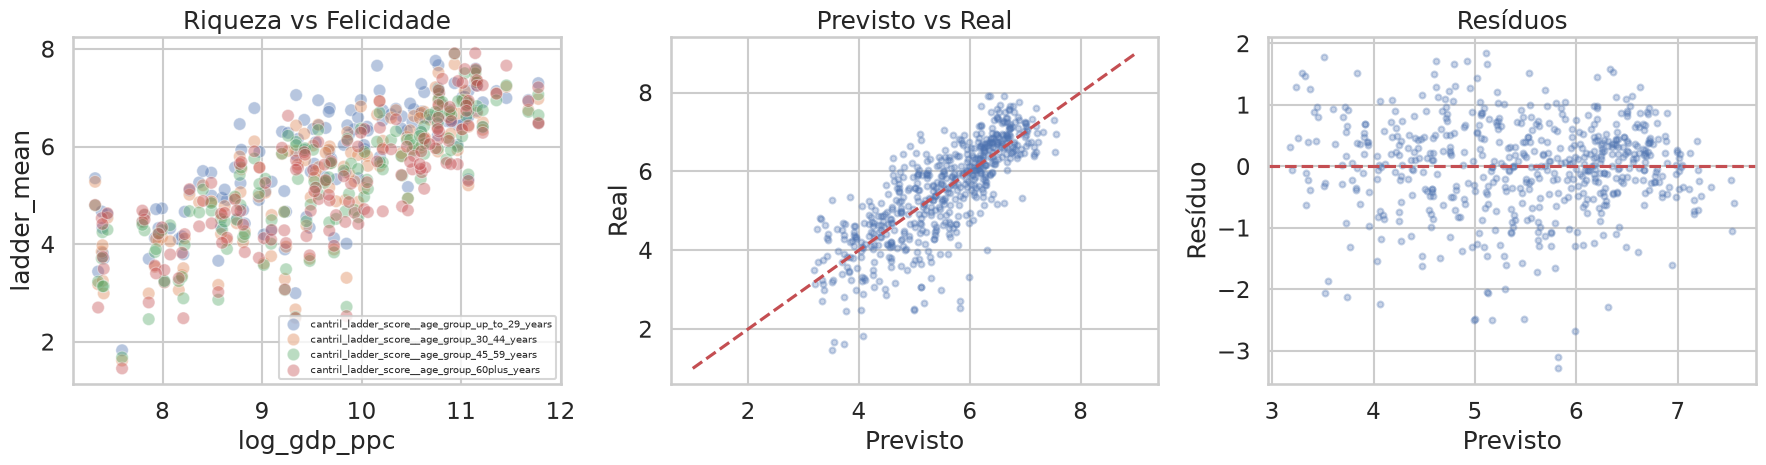


Países com maiores resíduos:
iso3
BWA    2.840435
LBN    2.496853
AFG    2.071359
Name: residual, dtype: float64


In [39]:
# M3 ajustado em todas as linhas
features_m3 = ["age_mid", "age_sq", "log_gdp_ppc", "log_pop", "log_area"]
m3 = LinearRegression().fit(X[features_m3], X["ladder_mean"])

coef_names = ["age_mid", "age_sq", "log_gdp_ppc", "log_pop", "log_area"]
for name, coef in zip(coef_names, m3.coef_):
    print(f"{name}: {coef:.4f}")
print(f"intercepto: {m3.intercept_:.4f}")

vertex_m3 = -m3.coef_[0] / (2 * m3.coef_[1])
print(f"\nIdade do mínimo (M3): {vertex_m3:.1f}")

# previsões da validação cruzada para os gráficos
_, _, pred_m3 = cv_scores(features_m3, target="ladder_mean")
X["predicted"] = pred_m3
X["residual"] = X["ladder_mean"] - X["predicted"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# gráfico 1: riqueza vs felicidade
sns.scatterplot(data=X, x="log_gdp_ppc", y="ladder_mean", hue="age_group",
                alpha=0.4, ax=axes[0])
axes[0].set_title("Riqueza vs Felicidade")
axes[0].legend(loc="lower right", fontsize=7)

# gráfico 2: previsto vs real
axes[1].scatter(X["predicted"], X["ladder_mean"], alpha=0.3, s=18)
axes[1].plot([1, 9], [1, 9], "r--")
axes[1].set_xlabel("Previsto")
axes[1].set_ylabel("Real")
axes[1].set_title("Previsto vs Real")

# gráfico 3: resíduos
axes[2].scatter(X["predicted"], X["residual"], alpha=0.3, s=18)
axes[2].axhline(0, color="r", linestyle="--")
axes[2].set_xlabel("Previsto")
axes[2].set_ylabel("Resíduo")
axes[2].set_title("Resíduos")

plt.tight_layout()
plt.show()

# 3 países com maiores resíduos
top_residuals = X.groupby("iso3")["residual"].apply(lambda x: x.abs().mean()) \
    .sort_values(ascending=False).head(3)
print("\nPaíses com maiores resíduos:")
print(top_residuals)

**O que esperar, e por quê.** As diferenças entre países são grandes perto das diferenças entre idades, então a idade sozinha explica muito pouco da nota bruta, mesmo quando o formato dela é claro dentro dos países. Se o R² de M1 e M2 ficar perto de zero enquanto o gráfico dentro dos países mostra uma curva clara, isso é um **resultado** a explicar no relatório, não um erro.

##### **Minhas conclusões da Parte 3**:

A idade sozinha explica muito pouco da felicidade bruta (R^2 é aproximadamente 0.01 para M1 e M2), confirmando que as diferenças entre países dominam as diferenças entre faixas etárias. Quando controlamos pela média do país (ladder_dev), a idade tem uma influência significativamente maior (R^2 = 0.38 para M2), indicando que o padrão existe dentro dos países mas é mascarado pela variação entre eles.

A adição dos controles econômicos em M3 eleva o R^2 para 0.62, com o log do PIB per capita sendo o preditor mais forte (β = 0.86), evidenciando que riqueza explica muito mais felicidade do que idade.

A curva em U clássica descrita no artigo do WEF não aparece claramente nos dados de 2021-2023, tendo em vista que o mínimo estimado é aos 62.8 anos, bem acima dos 40-50 anos reportados durante a leitura. Isso é consistente com o WHR 2024, que aponta que jovens nascidos após 1980 estão relativamente menos felizes do que gerações anteriores na mesma idade.

Os países com maiores resíduos (Botsuana, Líbano e Afeganistão) revelam o que o modelo não captura: desigualdade, instabilidade política e conflito, fatores que desconectam o PIB per capita da felicidade real da população.  

Links para leitura adicional sobre os países que apresentam os maiores resíduos:
- Botsuana: https://www.bbc.com/portuguese/articles/c51e65jljn6o
- Líbano: https://veja.abril.com.br/mundo/apagoes-fome-e-suicidios-o-dramatico-colapso-economico-do-libano/
- Afeganistão: https://www.bbc.com/portuguese/internacional-57516844


## 8. Parte 4: regressão logística, feliz ou não por idade e país

A regressão linear prevê uma nota; a regressão logística prevê a **probabilidade** de um grupo ser "feliz", o que exige um rótulo sim/não. Vocês vão definir o rótulo, treinar `LogisticRegression` e embrulhar o resultado em uma função que uma pessoa sem experiência em programação consiga usar: dê um país e uma idade, receba uma probabilidade.

$$P(\text{feliz} = 1 \mid x) = \frac{1}{1 + e^{-(\beta_0 + \beta_1\,\text{idade} + \beta_2\,\text{idade}^2 + \beta_3 \ln \text{PIB} + \beta_4 \ln \text{pop} + \beta_5 \ln \text{área})}}$$

**Tarefa 4.1. Definam o rótulo.** Chamem um grupo de feliz quando `ladder_mean` estiver acima da **mediana** de todos os grupos. A mediana dá classes balanceadas, então a acurácia faz sentido. Imprimam o limiar e a proporção de linhas felizes, e escrevam uma frase sobre como as conclusões mudariam com um limiar fixo, como 6,0.

**Tarefa 4.2. Treinem e avaliem em países não vistos.** Usem `GroupShuffleSplit` para que um país fique inteiro no treino ou inteiro no teste. Padronizem os atributos numéricos dentro de um `Pipeline`, para que a escala seja aprendida só com as linhas de treino. Reportem acurácia, AUC-ROC e a matriz de confusão.

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

THRESHOLD = df["ladder_mean"].median()
df["happy"] = (df["ladder_mean"] > THRESHOLD).astype(int)
print("limiar:", round(THRESHOLD, 2), "| proporção de felizes:", df["happy"].mean().round(2))

FEATURES = ["age_mid", "age_sq", "log_gdp_pc", "log_pop", "log_area"]   # acrescente suas colunas extras aqui

def make_classifier():
    return make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))

# TODO: GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE) com groups=df["iso3"]
# TODO: ajuste no treino, use predict_proba no teste e reporte acurácia, AUC e matriz de confusão

**Tarefa 4.3. Divisão aleatória versus divisão por país.** Repitam a 4.2 com um `train_test_split` aleatório comum. **Antes de rodar, prevejam** se a pontuação vai subir ou descer e por quê. Depois rodem as duas divisões com 20 sementes aleatórias diferentes e comparem as distribuições do AUC. Façam a mesma comparação com um `RandomForestClassifier` e expliquem o que viram.

**Tarefa 4.4. A função.** Implementem `check_happiness(country, age)` seguindo este contrato:

| Item | Requisito |
| --- | --- |
| Entrada | Nome de um país (qualquer grafia que o `to_iso3` entenda) e uma idade em anos |
| Busca | Encontra `log_gdp_pc`, `log_pop` e `log_area` do país na tabela combinada |
| Saída | Um dicionário com `country`, `age`, `p_happy` (arredondado para 3 casas) e `predicted` (`"happy"` se `p_happy` > 0,5, senão `"not happy"`) |
| Erros | Levanta `ValueError` com mensagem legível se o país for desconhecido ou não tiver dados do Banco Mundial |
| Modelo | Treinado uma vez com todas as linhas, **fora** da função, e passado como argumento padrão |

In [ ]:
final_clf = make_classifier().fit(df[FEATURES], df["happy"])
country_lookup = (df.drop_duplicates("iso3")
                    .set_index("iso3")[["country", "log_gdp_pc", "log_pop", "log_area"]])

def check_happiness(country: str, age: float, model=final_clf) -> dict:
    # Retorna P(feliz) e a classe prevista para um país em uma determinada idade.
    # TODO: 1) converta o nome para ISO3 com to_iso3(pd.Series([country]))
    # TODO: 2) se o ISO3 não estiver em country_lookup, levante ValueError com mensagem clara
    # TODO: 3) monte uma linha com age_mid=age, age_sq=age**2 e os 3 atributos do país (na ordem de FEATURES)
    # TODO: 4) calcule p com model.predict_proba e devolva o dicionário do contrato
    raise NotImplementedError

**Tarefa 4.5. Visualizem.** Chamem a função para idades de 18 a 85 anos, para cinco países de faixas de renda diferentes que vocês escolherem, e desenhem `sns.lineplot(data=curves, x="age", y="p_happy", hue="country")` com uma linha tracejada em 0,5. Olhem as pontas do eixo da idade: os dados só cobrem pontos médios de faixa de 22 a 70, então qualquer comportamento além disso é **extrapolação** de um polinômio quadrático, que pode virar de forma abrupta. Escrevam isso na legenda da figura.

In [ ]:
chosen = ["Brazil", "Finland", "India"]   # TODO: escolha 5 países de faixas de renda diferentes
ages = np.arange(18, 86, 2)

# TODO: monte "curves" (DataFrame com colunas age, country, p_happy) chamando check_happiness
# TODO: sns.lineplot(data=curves, x="age", y="p_happy", hue="country"); plt.axhline(0.5, ls="--", color="k")

Um ponto estrutural para discutir. As quatro linhas de um país compartilham o mesmo PIB, a mesma população e a mesma área, então o modelo só consegue separá-las pela idade. Expliquem o que isso implica sobre o quanto o modelo realmente "sabe" sobre cada país.

**Minhas conclusões da Parte 4** (editem esta célula):

...

## 9. Discussão (cerca de meia página, com as palavras de vocês)

Respondam nesta célula. Usem as frases do Passo 0 e os resultados das Partes 3 e 4.

1. O perfil de idade **dentro dos países** mostra uma curva em U? Onde fica o mínimo? Como isso se compara ao artigo do WEF e ao resumo do WHR 2024?
2. Comparem o tamanho do efeito da idade com o do efeito da riqueza. Qual pesa mais para prever a nota de um país, e qual pesa mais para prever diferenças **dentro** de um país?
3. As linhas de vocês são médias de grupos por país, não indivíduos. Por que um padrão nas médias pode falhar em descrever qualquer pessoa em particular (a **falácia ecológica**)?
4. A idade aqui é o ponto médio de quatro faixas. Que informação isso descartou, e como uma curva em U poderia parecer diferente com idades em anos simples?
5. Uma fotografia de muitos países mistura **idade** com **coorte de nascimento**. O WHR 2024 encontra avaliações de vida menores em quem nasceu depois de 1980. Por que não dá para separar um efeito de idade de um efeito de coorte com um único corte transversal?
6. O que a escolha do limiar de "feliz" fez com os resultados de classificação, e vocês confiariam em um ponto de corte de probabilidade 0,5 para uma política pública?

**Respostas da dupla:**

1. ...
2. ...
3. ...
4. ...
5. ...
6. ...

## 10. Entrega: GitHub (portfólio) e MS Teams

Este é um **projeto em dupla**. O prazo é o **final do dia da aula**, e o projeto **pode ser feito durante a aula de laboratório**. A entrega tem duas partes: publicar no GitHub e enviar o link no MS Teams.


### 10.1 Publicar no GitHub (item do portfólio)

1. Criem um repositório **público** no GitHub, por exemplo `felicidade-idade-pais`. Ele será um item do portfólio de vocês, então cuidem da apresentação.
2. Coloquem no repositório: este notebook (executado, **com as saídas salvas**), o `lab_helpers.py`, um `requirements.txt` e um `README.md`.
3. O `README.md` deve ter: título e uma frase de contexto; os nomes da dupla; como executar (versão do Python e `pip install -r requirements.txt`); duas ou três figuras principais e a conclusão em poucas linhas; limitações; e as **fontes citadas** (World Happiness Report, Our World in Data e Banco Mundial, com a data do download).
4. Os **dois integrantes** devem aparecer nos commits. Se um só fizer os commits, adicionem o outro como colaborador (*Settings → Collaborators*) e alternem quem faz o push.
5. Antes de publicar, rodem **Kernel → Restart & Run All** e salvem o notebook. O GitHub mostra as saídas gravadas no arquivo.


Estrutura sugerida:

```text
felicidade-idade-pais/
├── README.md
├── requirements.txt
├── lab_helpers.py
├── lab_felicidade_idade_pais.ipynb
└── figures/            (opcional: PNGs exportados)
```





Comandos básicos:

```bash
git init
git add .
git commit -m "Lab: felicidade por idade e país"
git branch -M main
git remote add origin https://github.com/<usuario>/<repositorio>.git
git push -u origin main
```








### 10.2 Enviar no MS Teams

Copiem o **link do repositório** (por exemplo `https://github.com/<usuario>/<repositorio>`) e enviem na **atividade correspondente do MS Teams**, antes do fim do prazo. Só um integrante precisa enviar, mas escrevam no texto da entrega os nomes dos dois. Confiram em uma janela anônima do navegador se o link abre sem login.

Conteúdo mínimo do `requirements.txt`:

```text
pandas
numpy
scikit-learn
seaborn
matplotlib
requests
openpyxl
country_converter
```



### 10.3 Avaliação

| Processo | Componente | Pontos |
| --- | --- | --- |
| ASK | Notas de leitura (uma frase por fonte) e parágrafo de contexto | 1 |
| GET, EXPLORE | Carga, enriquecimento e auditoria do *join* (países descartados listados e explicados) | 2 |
| MODEL | Regressão linear: figuras 3.1 a 3.4, tabela com três modelos, validação cruzada por país | 2 |
| MODEL | Regressão logística: rótulo, avaliação agrupada, `check_happiness`, curvas de probabilidade | 2 |
| COMMUNICATE | Discussão dos limites e interpretação honesta | 1,5 |
| COMMUNICATE | Publicação no GitHub e reprodutibilidade: README, `requirements.txt`, commits dos dois, notebook roda do início ao fim, sementes fixas, link enviado no Teams | 1,5 |
| **Total** | **10** |

> Esta atividade de LAB vai compor a média (QUIZ, LAB, LAB, LAB..., PROJETO)




### 10.4 Desafios extras (do mais simples ao mais difícil)

- Acrescentem uma variável de **região** e uma interação `idade × região` para testar a descoberta do WHR de que a América do Norte e a Europa Central e Oriental fogem do padrão em U.
- Comparem 2006-2010 com 2021-2023, se o professor fornecer as duas janelas, e testem se a felicidade dos jovens caiu.
- Regularizem com `Ridge` ou `LogisticRegression(C=...)` e escolham a força por validação cruzada agrupada.
- Desenhem uma **curva de calibração** do classificador e discutam se as probabilidades podem ser lidas como probabilidades.
- Troquem o limiar da mediana por um alvo ordinal e ajustem um modelo multiclasse.

### 10.5 Citações

Citem o **World Happiness Report**, o **Our World in Data** e o **Banco Mundial** no notebook e no README. Informem a **data exata do download** e os **anos** que os dados cobrem, porque essas fontes revisam suas séries. Façam o mesmo para cada conjunto de dados extra que acrescentarem: fonte, data do download, anos e chave de junção.

**Fontes das leituras:**

- [Gallup: World Happiness Report](https://www.gallup.com/analytics/349487/world-happiness-report.aspx)
- [WEF: At what age does happiness peak?](https://www.weforum.org/stories/wellbeing-and-mental-health/at-what-age-does-happiness-peak/)
- [WHR 2024: Happiness and age (resumo)](https://www.worldhappiness.report/ed/2024/happiness-and-age-summary/)
- [WHR 2024: Happiness of the younger, the older, and those in between](https://www.worldhappiness.report/ed/2024/happiness-of-the-younger-the-older-and-those-in-between/)
- [Our World in Data: Self-reported life satisfaction by age](https://ourworldindata.org/grapher/cantril-ladder-age-groups?tab=table)
- [The Happiness Curve (Macmillan)](https://us.macmillan.com/books/9781427292988/thehappinesscurve/)

## Modelos de Regressão

Principais tipos de modelos de regressão utilizados em Inteligência Artificial e Aprendizado de Máquina:

### Modelos de Regressão Clássicos e Estatísticos

* Regressão Linear: Modela uma relação linear entre variáveis. É usada para prever um valor numérico contínuo com base em uma reta que minimiza a distância entre os pontos dos dados.
* Regressão Logística: Classifica dados em categorias binárias (como sim/não). Apesar do nome "regressão", ela calcula a probabilidade de um evento acontecer usando uma curva sigmoide.
* Regressão Polinomial (e Quadrática): Estende a regressão linear para modelar relações curvas. A regressão quadrática adiciona variáveis ao quadrado ($x^2$) para desenhar uma parábola que se ajusta a padrões não lineares.
* Regressão Exponencial: Modela dados que crescem ou decrescem de forma acelerada. É ideal quando a taxa de variação da variável alvo é proporcional ao seu valor atual (como crescimento populacional).

### Modelos Avançados e Baseados em IA

* Árvores de Decisão para Regressão: Dividem os dados repetidamente em subgrupos com base em perguntas lógicas. A previsão final é a média dos valores do grupo em que o dado terminou.
* Random Forest (e Modelos de Ensemble): Combina dezenas de árvores de decisão independentes. A previsão final é a média dos resultados de todas as árvores, reduzindo erros e aumentando a precisão.
* Gradient Boosting (como XGBoost e LightGBM): Constrói árvores de decisão sequencialmente. Cada nova árvore é treinada especificamente para corrigir os erros cometidos pelas árvores anteriores.
* Máquinas de Vetores de Suporte (SVR): Encontra uma linha (ou hiperplano) de melhor ajuste dentro de uma margem de tolerância definida. Busca prever valores contínuos maximizando a distância entre os pontos mais distantes.
* Redes Neurais Artificiais (Deep Learning): Utiliza camadas de neurônios matemáticos interconectados. É capaz de aprender relações extremamente complexas e padrões altamente não lineares em grandes volumes de dados.

### Para aprender mais

Introduction to Machine Learning: Regression by Etienne Bernard<br>
https://www.wolfram.com/language/introduction-machine-learning/regression/


## Documentação

Documentação online atualizada:

- https://scikit-learn.org/stable/user_guide.html
- https://pandas.pydata.org/getting_started.html
- https://numpy.org/learn/
- https://requests.readthedocs.io/en/latest/
- https://pythonfluente.com/2/
- https://git-scm.com/docs

## Bibliografia

- Python Data Science Handbook: https://jakevdp.github.io/PythonDataScienceHandbook/
- Artificial Intelligence: A Modern Approach, 4th US ed: https://aima.cs.berkeley.edu/
- An Introduction to Statistical Learning, Python: https://www.statlearning.com/
- Introduction to Machine Learning (Etienne Bernard): https://www.wolfram.com/language/introduction-machine-learning/

## Infográficos

![](https://helloskillio.com/wp-content/uploads/2025/10/What-is-Pair-Programming-A-Complete-Guide-for-Beginners.webp)

![](https://statisticalanalysishelp.com/wp-content/uploads/2026/05/Untitled-design-5-1024x683.jpg)

https://statisticalanalysishelp.com/difference-between-logistic-and-linear-regression/

![](https://www.otechtalks.tv/wp-content/uploads/2020/04/data-science-process.jpg)